In [1]:
import yfinance as yf
import pandas as pd

In [2]:
ticker = yf.Ticker("NVDA")

data = ticker.history(period="1y")

data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-09-18 00:00:00-04:00,173.564178,176.676732,172.546627,175.818787,191763300,0.0,0.0
2025-09-19 00:00:00-04:00,175.349884,177.654360,174.761282,176.247726,237182100,0.0,0.0
2025-09-22 00:00:00-04:00,174.881022,184.108914,174.292436,183.171158,269637000,0.0,0.0
2025-09-23 00:00:00-04:00,181.535088,181.984009,175.788860,178.003540,192559600,0.0,0.0
2025-09-24 00:00:00-04:00,179.340323,179.350294,174.980758,176.547012,143564100,0.0,0.0


In [3]:
data.shape

(251, 7)

In [4]:
print("===== DATA SHAPE =====")
print(data.shape)

print("\n===== DATA INFO =====")
data.info()

print("\n===== STATISTICAL SUMMARY =====")
print(data.describe())

print("\n===== COLUMNS =====")
print(data.columns.tolist())

print("\n===== MISSING VALUES =====")
print(data.isnull().sum())

===== DATA SHAPE =====
(251, 7)

===== DATA INFO =====
<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-09-18 00:00:00-04:00 to 2026-09-17 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          251 non-null    float64
 1   High          251 non-null    float64
 2   Low           251 non-null    float64
 3   Close         251 non-null    float64
 4   Volume        251 non-null    int64  
 5   Dividends     251 non-null    float64
 6   Stock Splits  251 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.7 KB

===== STATISTICAL SUMMARY =====
             Open        High         Low       Close        Volume  \
count  251.000000  251.000000  251.000000  251.000000  2.510000e+02   
mean   195.686614  198.421127  192.613451  195.444126  1.651515e+08   
std     15.895179   16.063919   15.564501   15.687430  4.957991e+07   
min    166.589225  169.063558  163.895378  164.7

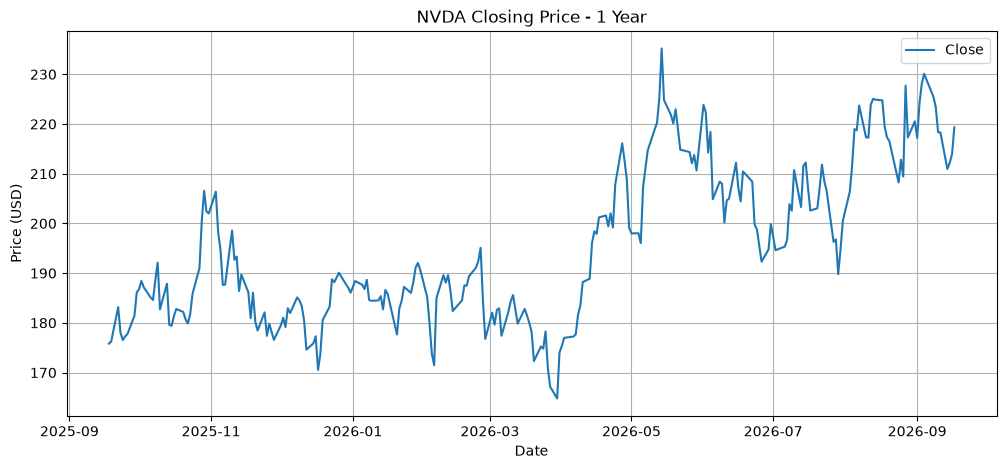

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(data.index, data["Close"], label="Close")

plt.title("NVDA Closing Price - 1 Year")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)

plt.show()

In [6]:
print("===== FIRST 5 TRADING DAYS =====")
print(data[["Open", "High", "Low", "Close", "Volume"]].head())

print("\n===== LAST 5 TRADING DAYS =====")
print(data[["Open", "High", "Low", "Close", "Volume"]].tail())

===== FIRST 5 TRADING DAYS =====
                                 Open        High         Low       Close  \
Date                                                                        
2025-09-18 00:00:00-04:00  173.564178  176.676732  172.546627  175.818787   
2025-09-19 00:00:00-04:00  175.349884  177.654360  174.761282  176.247726   
2025-09-22 00:00:00-04:00  174.881022  184.108914  174.292436  183.171158   
2025-09-23 00:00:00-04:00  181.535088  181.984009  175.788860  178.003540   
2025-09-24 00:00:00-04:00  179.340323  179.350294  174.980758  176.547012   

                              Volume  
Date                                  
2025-09-18 00:00:00-04:00  191763300  
2025-09-19 00:00:00-04:00  237182100  
2025-09-22 00:00:00-04:00  269637000  
2025-09-23 00:00:00-04:00  192559600  
2025-09-24 00:00:00-04:00  143564100  

===== LAST 5 TRADING DAYS =====
                                 Open        High         Low       Close  \
Date                                        

In [7]:
# Daily percentage return
data["Daily_Return"] = data["Close"].pct_change() * 100

print("===== DAILY RETURN =====")
print(data[["Close", "Daily_Return"]].head(10))

print("\n===== RETURN SUMMARY =====")
print(data["Daily_Return"].describe())

print("\n===== HIGHEST DAILY RETURN =====")
print(data["Daily_Return"].max())

print("\n===== LOWEST DAILY RETURN =====")
print(data["Daily_Return"].min())

===== DAILY RETURN =====
                                Close  Daily_Return
Date                                               
2025-09-18 00:00:00-04:00  175.818787           NaN
2025-09-19 00:00:00-04:00  176.247726      0.243967
2025-09-22 00:00:00-04:00  183.171158      3.928239
2025-09-23 00:00:00-04:00  178.003540     -2.821196
2025-09-24 00:00:00-04:00  176.547012     -0.818258
2025-09-25 00:00:00-04:00  177.265320      0.406865
2025-09-26 00:00:00-04:00  177.764114      0.281383
2025-09-29 00:00:00-04:00  181.415375      2.053992
2025-09-30 00:00:00-04:00  186.134048      2.601033
2025-10-01 00:00:00-04:00  186.792480      0.353741

===== RETURN SUMMARY =====
count    250.000000
mean       0.117033
std        2.397469
min       -6.201409
25%       -1.409966
50%        0.092107
75%        1.716645
max        8.737953
Name: Daily_Return, dtype: float64

===== HIGHEST DAILY RETURN =====
8.737952570943941

===== LOWEST DAILY RETURN =====
-6.2014093111784625


In [8]:
# Rolling 20-day volatility
data["Volatility_20D"] = data["Daily_Return"].rolling(window=20).std()

print("===== 20-DAY ROLLING VOLATILITY =====")
print(data[["Daily_Return", "Volatility_20D"]].tail(10))

print("\n===== VOLATILITY SUMMARY =====")
print(data["Volatility_20D"].describe())

===== 20-DAY ROLLING VOLATILITY =====
                           Daily_Return  Volatility_20D
Date                                                   
2026-09-03 00:00:00-04:00      1.800273        2.903524
2026-09-04 00:00:00-04:00      0.836070        2.868554
2026-09-08 00:00:00-04:00     -2.009901        2.827028
2026-09-09 00:00:00-04:00     -0.912593        2.838060
2026-09-10 00:00:00-04:00     -2.264792        2.804720
2026-09-11 00:00:00-04:00     -0.032061        2.800900
2026-09-14 00:00:00-04:00     -3.357912        2.893004
2026-09-15 00:00:00-04:00      0.573564        2.899034
2026-09-16 00:00:00-04:00      0.815382        2.864807
2026-09-17 00:00:00-04:00      2.543246        2.914905

===== VOLATILITY SUMMARY =====
count    231.000000
mean       2.409690
std        0.370661
min        1.522405
25%        2.131831
50%        2.430922
75%        2.739932
max        3.038169
Name: Volatility_20D, dtype: float64


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


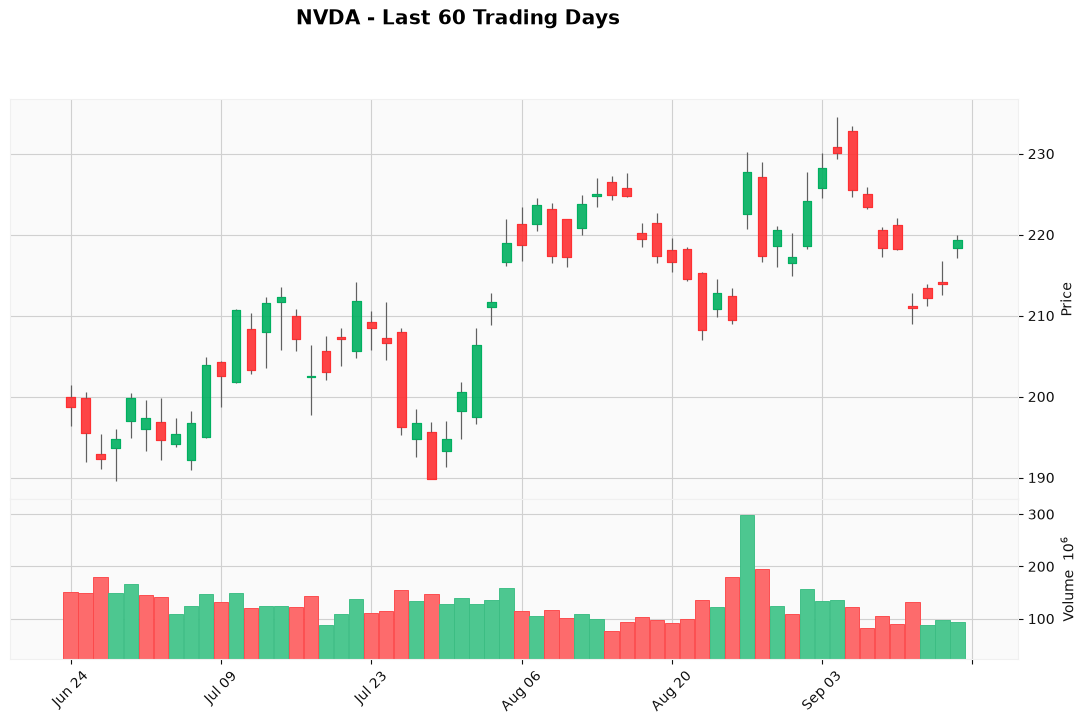

In [10]:
import mplfinance as mpf

# Last 60 trading days
recent_data = data.tail(60)

mpf.plot(
    recent_data,
    type="candle",
    volume=True,
    style="yahoo",
    title="NVDA - Last 60 Trading Days",
    figsize=(14, 8)
)

In [11]:
print("Before Cleaning:")
print(data.shape)

# Remove rows where calculated features are missing
clean_data = data.dropna().copy()

print("\nAfter Cleaning:")
print(clean_data.shape)

print("\nMissing Values:")

print(clean_data.isnull().sum())

Before Cleaning:
(251, 9)

After Cleaning:
(231, 9)

Missing Values:
Open              0
High              0
Low               0
Close             0
Volume            0
Dividends         0
Stock Splits      0
Daily_Return      0
Volatility_20D    0
dtype: int64


In [12]:
print("===== CLEAN DATA SHAPE =====")
print(clean_data.shape)

print("\n===== CLEAN DATA COLUMNS =====")
print(clean_data.columns.tolist())

print("\n===== LAST 5 ROWS =====")
print(clean_data.tail())

# Save cleaned dataset
clean_data.to_csv("../data/NVDA_clean.csv")

print("\n===== FILE SAVED =====")
print("NVDA_clean.csv saved successfully!")

===== CLEAN DATA SHAPE =====
(231, 9)

===== CLEAN DATA COLUMNS =====
['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Daily_Return', 'Volatility_20D']

===== LAST 5 ROWS =====
                                 Open        High         Low       Close  \
Date                                                                        
2026-09-11 00:00:00-04:00  221.240005  222.000000  218.149994  218.289993   
2026-09-14 00:00:00-04:00  211.240005  212.770004  208.929993  210.960007   
2026-09-15 00:00:00-04:00  213.380005  213.940002  211.160004  212.169998   
2026-09-16 00:00:00-04:00  214.139999  216.759995  212.500000  213.899994   
2026-09-17 00:00:00-04:00  218.380005  219.910004  217.149994  219.339996   

                              Volume  Dividends  Stock Splits  Daily_Return  \
Date                                                                          
2026-09-11 00:00:00-04:00   89060100        0.0           0.0     -0.032061   
2026-09-14 00:00:00-04

In [13]:
# Calculate moving averages
clean_data["SMA_20"] = clean_data["Close"].rolling(window=20).mean()
clean_data["SMA_50"] = clean_data["Close"].rolling(window=50).mean()

print("===== MOVING AVERAGES =====")
print(clean_data[["Close", "SMA_20", "SMA_50"]].tail(10))

print("\n===== MISSING VALUES =====")
print(clean_data[["SMA_20", "SMA_50"]].isnull().sum())

===== MOVING AVERAGES =====
                                Close      SMA_20      SMA_50
Date                                                         
2026-09-03 00:00:00-04:00  228.194656  219.516371  209.639421
2026-09-04 00:00:00-04:00  230.102524  219.836013  210.331047
2026-09-08 00:00:00-04:00  225.477692  220.244556  210.994305
2026-09-09 00:00:00-04:00  223.419998  220.552711  211.567664
2026-09-10 00:00:00-04:00  218.360001  220.278735  211.937537
2026-09-11 00:00:00-04:00  218.289993  219.940825  212.356153
2026-09-14 00:00:00-04:00  210.960007  219.243408  212.683109
2026-09-15 00:00:00-04:00  212.169998  218.613983  213.019880
2026-09-16 00:00:00-04:00  213.899994  218.334263  213.363682
2026-09-17 00:00:00-04:00  219.339996  218.435421  213.672645

===== MISSING VALUES =====
SMA_20    19
SMA_50    49
dtype: int64


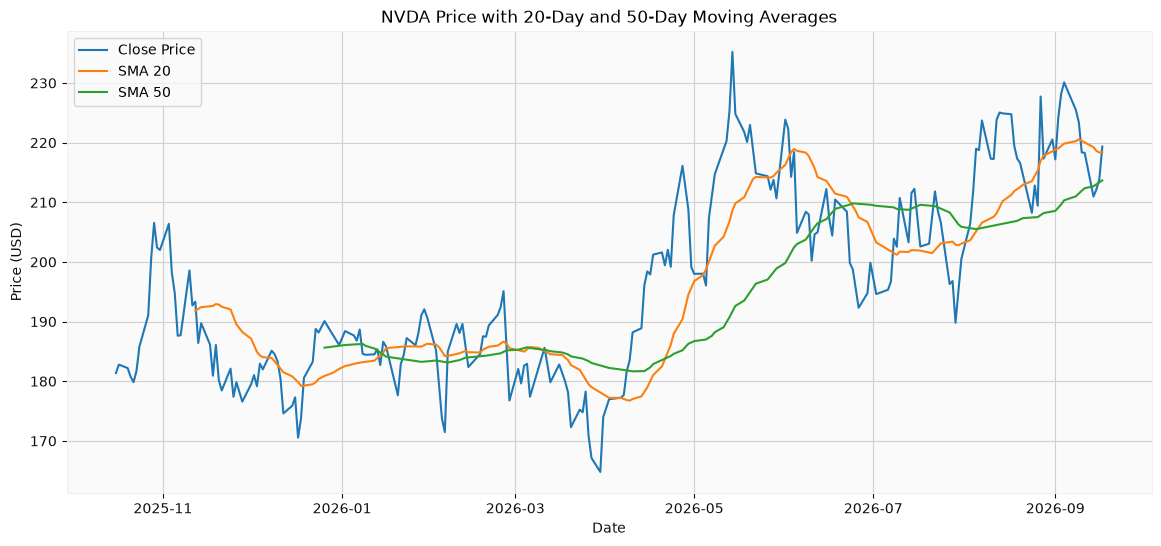

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(
    clean_data.index,
    clean_data["Close"],
    label="Close Price"
)

plt.plot(
    clean_data.index,
    clean_data["SMA_20"],
    label="SMA 20"
)

plt.plot(
    clean_data.index,
    clean_data["SMA_50"],
    label="SMA 50"
)

plt.title("NVDA Price with 20-Day and 50-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)

plt.show()

In [15]:
clean_data["SMA_Trend"] = clean_data["SMA_20"] - clean_data["SMA_50"]

In [16]:
# Calculate 20-day Exponential Moving Average
clean_data["EMA_20"] = clean_data["Close"].ewm(
    span=20,
    adjust=False
).mean()

print("===== EMA 20 =====")
print(clean_data[["Close", "SMA_20", "EMA_20"]].tail(10))

print("\n===== MISSING VALUES =====")
print(clean_data["EMA_20"].isnull().sum())

===== EMA 20 =====
                                Close      SMA_20      EMA_20
Date                                                         
2026-09-03 00:00:00-04:00  228.194656  219.516371  217.891275
2026-09-04 00:00:00-04:00  230.102524  219.836013  219.054251
2026-09-08 00:00:00-04:00  225.477692  220.244556  219.666007
2026-09-09 00:00:00-04:00  223.419998  220.552711  220.023530
2026-09-10 00:00:00-04:00  218.360001  220.278735  219.865099
2026-09-11 00:00:00-04:00  218.289993  219.940825  219.715089
2026-09-14 00:00:00-04:00  210.960007  219.243408  218.881271
2026-09-15 00:00:00-04:00  212.169998  218.613983  218.242102
2026-09-16 00:00:00-04:00  213.899994  218.334263  217.828568
2026-09-17 00:00:00-04:00  219.339996  218.435421  217.972514

===== MISSING VALUES =====
0


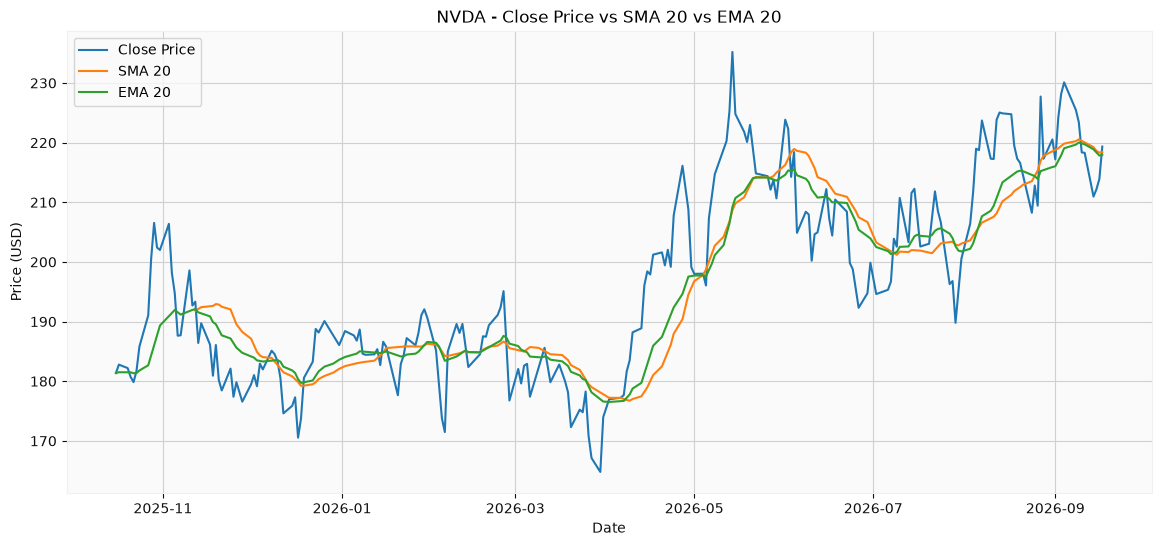

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    clean_data.index,
    clean_data["Close"],
    label="Close Price"
)

plt.plot(
    clean_data.index,
    clean_data["SMA_20"],
    label="SMA 20"
)

plt.plot(
    clean_data.index,
    clean_data["EMA_20"],
    label="EMA 20"
)

plt.title("NVDA - Close Price vs SMA 20 vs EMA 20")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
# Calculate RSI using 14 trading days

delta = clean_data["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

clean_data["RSI_14"] = 100 - (100 / (1 + rs))

print("===== RSI 14 =====")
print(clean_data[["Close", "RSI_14"]].tail(10))

print("\n===== RSI SUMMARY =====")
print(clean_data["RSI_14"].describe())

print("\n===== MISSING VALUES =====")
print(clean_data["RSI_14"].isnull().sum())

===== RSI 14 =====
                                Close     RSI_14
Date                                            
2026-09-03 00:00:00-04:00  228.194656  52.317877
2026-09-04 00:00:00-04:00  230.102524  53.677991
2026-09-08 00:00:00-04:00  225.477692  54.154520
2026-09-09 00:00:00-04:00  223.419998  54.244821
2026-09-10 00:00:00-04:00  218.360001  51.149237
2026-09-11 00:00:00-04:00  218.289993  52.567971
2026-09-14 00:00:00-04:00  210.960007  51.801966
2026-09-15 00:00:00-04:00  212.169998  49.553786
2026-09-16 00:00:00-04:00  213.899994  53.183739
2026-09-17 00:00:00-04:00  219.339996  42.696989

===== RSI SUMMARY =====
count    217.000000
mean      52.097383
std       12.938716
min       26.057201
25%       42.880355
50%       50.000000
75%       59.239864
max       98.629053
Name: RSI_14, dtype: float64

===== MISSING VALUES =====
14


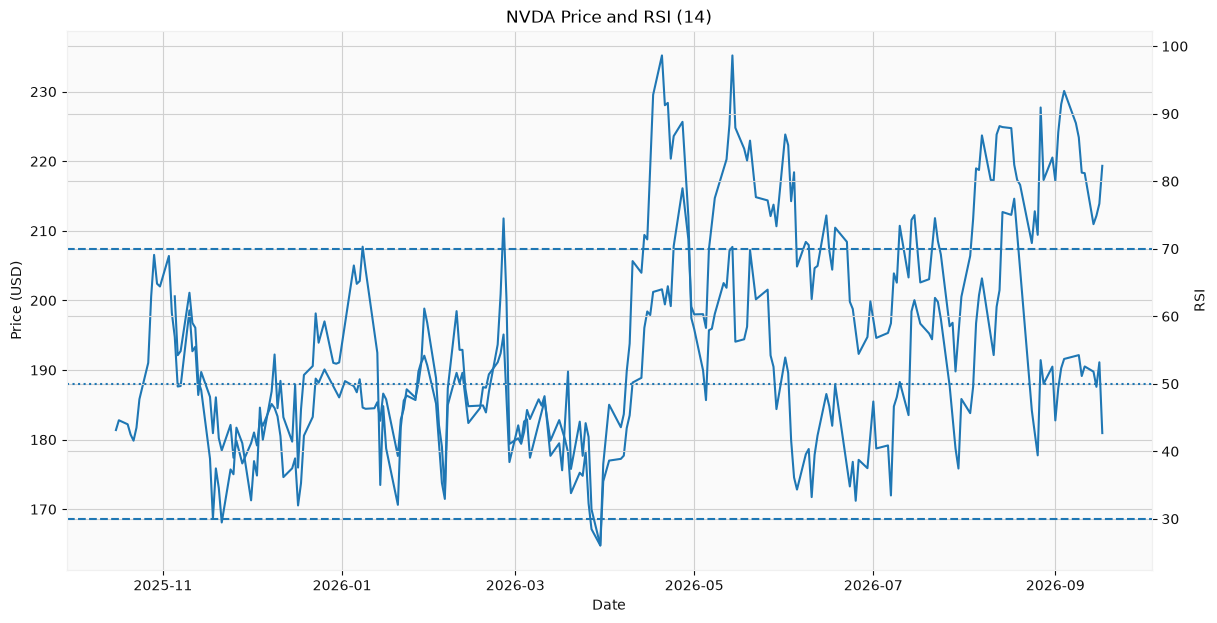

In [19]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Price
ax1.plot(
    clean_data.index,
    clean_data["Close"],
    label="Close Price"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Price (USD)")
ax1.grid(True)

# RSI
ax2 = ax1.twinx()

ax2.plot(
    clean_data.index,
    clean_data["RSI_14"],
    label="RSI 14"
)

ax2.axhline(70, linestyle="--", label="RSI 70")
ax2.axhline(30, linestyle="--", label="RSI 30")
ax2.axhline(50, linestyle=":", label="RSI 50")

ax2.set_ylabel("RSI")

plt.title("NVDA Price and RSI (14)")
plt.show()

In [20]:
# MACD calculation

ema_12 = clean_data["Close"].ewm(
    span=12,
    adjust=False
).mean()

ema_26 = clean_data["Close"].ewm(
    span=26,
    adjust=False
).mean()

# MACD Line
clean_data["MACD"] = ema_12 - ema_26

# Signal Line
clean_data["MACD_Signal"] = clean_data["MACD"].ewm(
    span=9,
    adjust=False
).mean()

# Histogram
clean_data["MACD_Histogram"] = (
    clean_data["MACD"] - clean_data["MACD_Signal"]
)

print("===== MACD =====")
print(
    clean_data[
        ["Close", "MACD", "MACD_Signal", "MACD_Histogram"]
    ].tail(10)
)

print("\n===== MISSING VALUES =====")
print(
    clean_data[
        ["MACD", "MACD_Signal", "MACD_Histogram"]
    ].isnull().sum()
)

===== MACD =====
                                Close      MACD  MACD_Signal  MACD_Histogram
Date                                                                        
2026-09-03 00:00:00-04:00  228.194656  3.252740     2.784325        0.468415
2026-09-04 00:00:00-04:00  230.102524  3.828618     2.993184        0.835434
2026-09-08 00:00:00-04:00  225.477692  3.867241     3.167995        0.699246
2026-09-09 00:00:00-04:00  223.419998  3.689283     3.272253        0.417031
2026-09-10 00:00:00-04:00  218.360001  3.104168     3.238636       -0.134468
2026-09-11 00:00:00-04:00  218.289993  2.604785     3.111865       -0.507081
2026-09-14 00:00:00-04:00  210.960007  1.599118     2.809316       -1.210198
2026-09-15 00:00:00-04:00  212.169998  0.889502     2.425353       -1.535851
2026-09-16 00:00:00-04:00  213.899994  0.461404     2.032563       -1.571160
2026-09-17 00:00:00-04:00  219.339996  0.554701     1.736991       -1.182290

===== MISSING VALUES =====
MACD              0
MACD_Signal

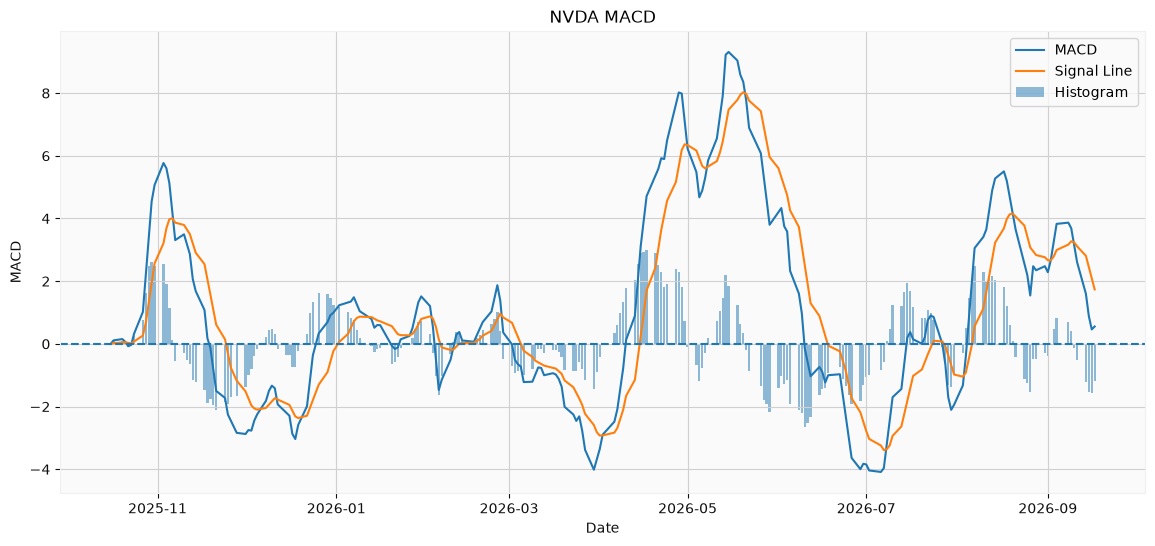

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    clean_data.index,
    clean_data["MACD"],
    label="MACD"
)

ax.plot(
    clean_data.index,
    clean_data["MACD_Signal"],
    label="Signal Line"
)

ax.bar(
    clean_data.index,
    clean_data["MACD_Histogram"],
    label="Histogram",
    alpha=0.5
)

ax.axhline(0, linestyle="--")

ax.set_title("NVDA MACD")
ax.set_xlabel("Date")
ax.set_ylabel("MACD")

ax.legend()
ax.grid(True)

plt.show()

In [22]:
# 20-day average volume
clean_data["Volume_SMA_20"] = (
    clean_data["Volume"]
    .rolling(window=20)
    .mean()
)

# Volume relative to its 20-day average
clean_data["Volume_Ratio"] = (
    clean_data["Volume"] / clean_data["Volume_SMA_20"]
)

print("===== VOLUME FEATURES =====")
print(
    clean_data[
        ["Volume", "Volume_SMA_20", "Volume_Ratio"]
    ].tail(10)
)

print("\n===== VOLUME RATIO SUMMARY =====")
print(clean_data["Volume_Ratio"].describe())

print("\n===== MISSING VALUES =====")
print(
    clean_data[
        ["Volume_SMA_20", "Volume_Ratio"]
    ].isnull().sum()
)

===== VOLUME FEATURES =====
                              Volume  Volume_SMA_20  Volume_Ratio
Date                                                             
2026-09-03 00:00:00-04:00  134681600    127435950.0      1.056857
2026-09-04 00:00:00-04:00  135352400    128920100.0      1.049894
2026-09-08 00:00:00-04:00  122965600    129276050.0      0.951186
2026-09-09 00:00:00-04:00   82955500    128360170.0      0.646271
2026-09-10 00:00:00-04:00  105768000    128209390.0      0.824963
2026-09-11 00:00:00-04:00   89060100    127719035.0      0.697313
2026-09-14 00:00:00-04:00  132267200    130548350.0      1.013166
2026-09-15 00:00:00-04:00   88059700    130267400.0      0.675992
2026-09-16 00:00:00-04:00   96563600    129939170.0      0.743145
2026-09-17 00:00:00-04:00   93960500    129797330.0      0.723902

===== VOLUME RATIO SUMMARY =====
count    212.000000
mean       0.978498
std        0.246678
min        0.379068
25%        0.823541
50%        0.928564
75%        1.077459
max   

In [23]:
print("===== ALL FEATURES =====")
print(clean_data.columns.tolist())

print("\n===== DATA SHAPE =====")
print(clean_data.shape)

print("\n===== MISSING VALUES =====")
print(clean_data.isnull().sum())

print("\n===== LAST 5 ROWS OF FEATURES =====")
print(
    clean_data[
        [
            "Close",
            "Daily_Return",
            "Volatility_20D",
            "SMA_20",
            "SMA_50",
            "EMA_20",
            "RSI_14",
            "MACD",
            "MACD_Signal",
            "MACD_Histogram",
            "Volume",
            "Volume_SMA_20",
            "Volume_Ratio"
        ]
    ].tail()
)

===== ALL FEATURES =====
['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Daily_Return', 'Volatility_20D', 'SMA_20', 'SMA_50', 'SMA_Trend', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'Volume_SMA_20', 'Volume_Ratio']

===== DATA SHAPE =====
(231, 19)

===== MISSING VALUES =====
Open               0
High               0
Low                0
Close              0
Volume             0
Dividends          0
Stock Splits       0
Daily_Return       0
Volatility_20D     0
SMA_20            19
SMA_50            49
SMA_Trend         49
EMA_20             0
RSI_14            14
MACD               0
MACD_Signal        0
MACD_Histogram     0
Volume_SMA_20     19
Volume_Ratio      19
dtype: int64

===== LAST 5 ROWS OF FEATURES =====
                                Close  Daily_Return  Volatility_20D  \
Date                                                                  
2026-09-11 00:00:00-04:00  218.289993     -0.032061        2.800900   
2026-09-14 00:00:0

===== CORRELATION MATRIX =====
                Close  Daily_Return  Volatility_20D  SMA_20  SMA_50  \
Close            1.00          0.16            0.46    0.84    0.68   
Daily_Return     0.16          1.00           -0.00   -0.05   -0.04   
Volatility_20D   0.46         -0.00            1.00    0.63    0.57   
SMA_20           0.84         -0.05            0.63    1.00    0.87   
SMA_50           0.68         -0.04            0.57    0.87    1.00   
SMA_Trend        0.58         -0.04            0.33    0.59    0.11   
EMA_20           0.89         -0.05            0.60    0.99    0.87   
RSI_14           0.38          0.17           -0.19   -0.08   -0.15   
MACD             0.65         -0.02            0.03    0.33   -0.03   
MACD_Signal      0.63         -0.07            0.17    0.50    0.06   
MACD_Histogram   0.20          0.11           -0.32   -0.30   -0.22   
Volume          -0.31         -0.00           -0.00   -0.24   -0.38   
Volume_SMA_20   -0.69         -0.06           

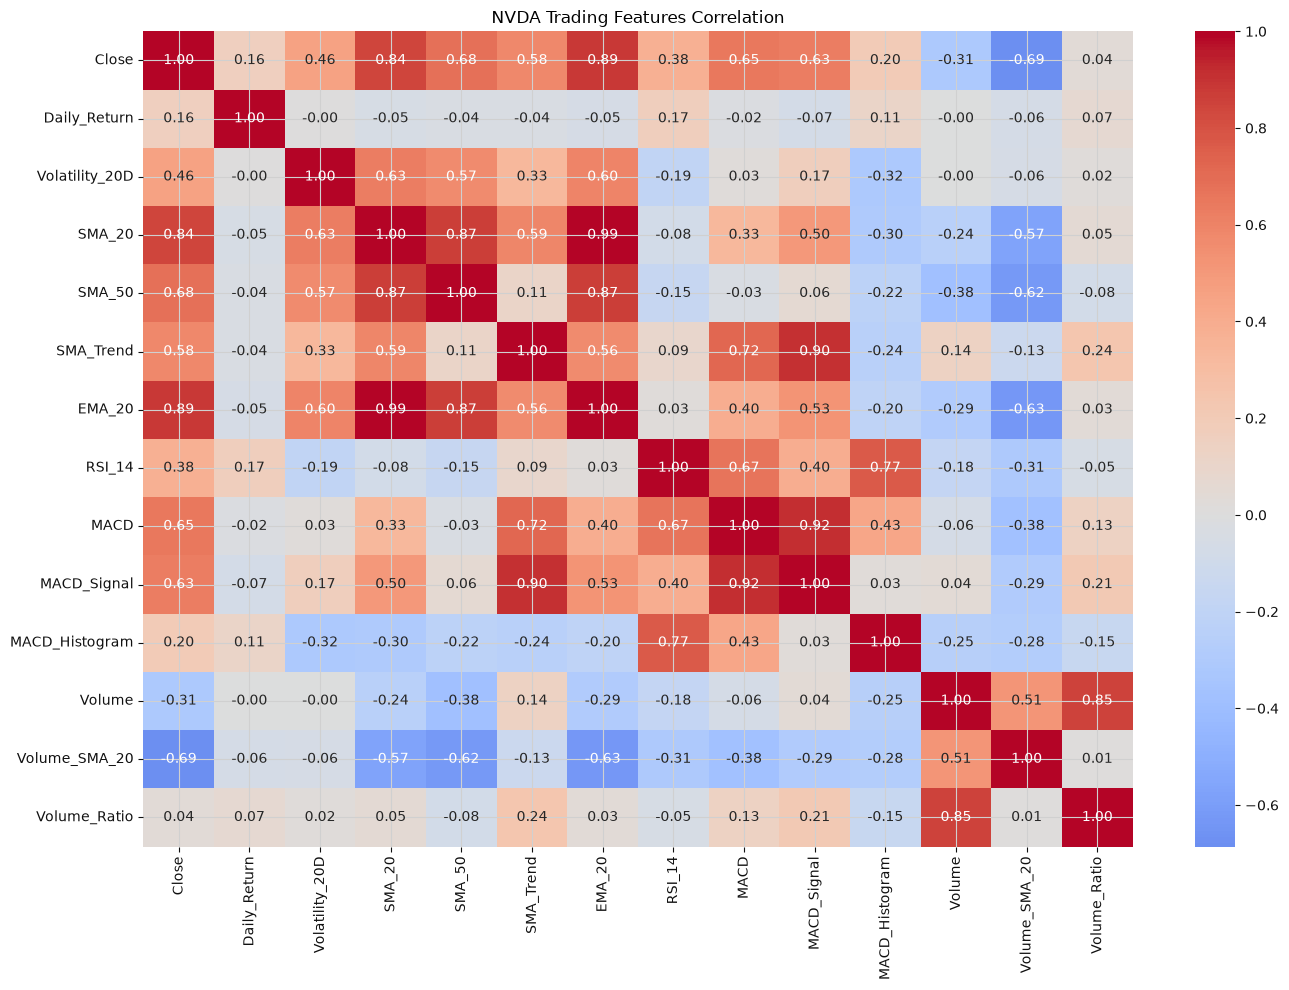

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Temporary dataset for correlation analysis
corr_data = clean_data.dropna().copy()

# Select numerical trading features
feature_columns = [
    "Close",
    "Daily_Return",
    "Volatility_20D",
    "SMA_20",
    "SMA_50",
    "SMA_Trend",
    "EMA_20",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "MACD_Histogram",
    "Volume",
    "Volume_SMA_20",
    "Volume_Ratio"
]

correlation = corr_data[feature_columns].corr()

print("===== CORRELATION MATRIX =====")
print(correlation.round(2))

print("\n===== CORRELATION DATA SHAPE =====")
print(correlation.shape)

# Heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("NVDA Trading Features Correlation")
plt.tight_layout()
plt.show()

In [26]:
# Create next day's closing price
clean_data["Next_Close"] = clean_data["Close"].shift(-1)

# Create target
# 1 = next day's price goes UP
# 0 = next day's price goes DOWN or stays same
clean_data["Target"] = (
    clean_data["Next_Close"] > clean_data["Close"]
).astype(int)

print("===== TARGET DATA =====")
print(
    clean_data[
        ["Close", "Next_Close", "Target"]
    ].tail(10)
)

print("\n===== TARGET DISTRIBUTION =====")
print(clean_data["Target"].value_counts())

print("\n===== TARGET PERCENTAGE =====")
print(
    clean_data["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

===== TARGET DATA =====
                                Close  Next_Close  Target
Date                                                     
2026-09-03 00:00:00-04:00  228.194656  230.102524       1
2026-09-04 00:00:00-04:00  230.102524  225.477692       0
2026-09-08 00:00:00-04:00  225.477692  223.419998       0
2026-09-09 00:00:00-04:00  223.419998  218.360001       0
2026-09-10 00:00:00-04:00  218.360001  218.289993       0
2026-09-11 00:00:00-04:00  218.289993  210.960007       0
2026-09-14 00:00:00-04:00  210.960007  212.169998       1
2026-09-15 00:00:00-04:00  212.169998  213.899994       1
2026-09-16 00:00:00-04:00  213.899994  219.339996       1
2026-09-17 00:00:00-04:00  219.339996         NaN       0

===== TARGET DISTRIBUTION =====
Target
1    116
0    115
Name: count, dtype: int64

===== TARGET PERCENTAGE =====
Target
1    50.22
0    49.78
Name: proportion, dtype: float64


In [27]:
# Remove the last row because there is no next-day price
clean_data = clean_data.dropna(subset=["Next_Close"]).copy()

print("===== AFTER TARGET CLEANING =====")
print("Shape:", clean_data.shape)

print("\n===== TARGET DISTRIBUTION =====")
print(clean_data["Target"].value_counts())

print("\n===== TARGET PERCENTAGE =====")
print(
    clean_data["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n===== CHECK MISSING VALUES =====")
print(
    clean_data[
        ["Next_Close", "Target"]
    ].isnull().sum()
)

===== AFTER TARGET CLEANING =====
Shape: (230, 21)

===== TARGET DISTRIBUTION =====
Target
1    116
0    114
Name: count, dtype: int64

===== TARGET PERCENTAGE =====
Target
1    50.43
0    49.57
Name: proportion, dtype: float64

===== CHECK MISSING VALUES =====
Next_Close    0
Target        0
dtype: int64


In [28]:
# Create final ML dataset
ml_data = clean_data.dropna().copy()

print("===== FINAL ML DATASET =====")
print("Shape:", ml_data.shape)

print("\n===== MISSING VALUES =====")
print(ml_data.isnull().sum())

print("\n===== TARGET DISTRIBUTION =====")
print(ml_data["Target"].value_counts())

print("\n===== FINAL COLUMNS =====")
print(ml_data.columns.tolist())

print("\n===== LAST 5 ROWS =====")
print(
    ml_data[
        [
            "Close",
            "Daily_Return",
            "Volatility_20D",
            "SMA_20",
            "SMA_50",
            "SMA_Trend",
            "EMA_20",
            "RSI_14",
            "MACD",
            "MACD_Signal",
            "MACD_Histogram",
            "Volume",
            "Volume_SMA_20",
            "Volume_Ratio",
            "Target"
        ]
    ].tail()
)

===== FINAL ML DATASET =====
Shape: (181, 21)

===== MISSING VALUES =====
Open              0
High              0
Low               0
Close             0
Volume            0
Dividends         0
Stock Splits      0
Daily_Return      0
Volatility_20D    0
SMA_20            0
SMA_50            0
SMA_Trend         0
EMA_20            0
RSI_14            0
MACD              0
MACD_Signal       0
MACD_Histogram    0
Volume_SMA_20     0
Volume_Ratio      0
Next_Close        0
Target            0
dtype: int64

===== TARGET DISTRIBUTION =====
Target
1    91
0    90
Name: count, dtype: int64

===== FINAL COLUMNS =====
['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Daily_Return', 'Volatility_20D', 'SMA_20', 'SMA_50', 'SMA_Trend', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'Volume_SMA_20', 'Volume_Ratio', 'Next_Close', 'Target']

===== LAST 5 ROWS =====
                                Close  Daily_Return  Volatility_20D  \
Date                           

In [29]:
# Features used by the ML model
feature_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Daily_Return",
    "Volatility_20D",
    "SMA_20",
    "SMA_50",
    "SMA_Trend",
    "EMA_20",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "MACD_Histogram",
    "Volume_SMA_20",
    "Volume_Ratio"
]

# X = input features
X = ml_data[feature_columns].copy()

# y = target
y = ml_data["Target"].copy()

print("===== X FEATURES =====")
print(X.columns.tolist())

print("\n===== X SHAPE =====")
print(X.shape)

print("\n===== y SHAPE =====")
print(y.shape)

print("\n===== TARGET DISTRIBUTION =====")
print(y.value_counts())

print("\n===== CHECK FUTURE COLUMNS =====")
print("Next_Close in X:", "Next_Close" in X.columns)

===== X FEATURES =====
['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Volatility_20D', 'SMA_20', 'SMA_50', 'SMA_Trend', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'Volume_SMA_20', 'Volume_Ratio']

===== X SHAPE =====
(181, 17)

===== y SHAPE =====
(181,)

===== TARGET DISTRIBUTION =====
Target
1    91
0    90
Name: count, dtype: int64

===== CHECK FUTURE COLUMNS =====
Next_Close in X: False


In [30]:
# Time-based train-test split

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("===== TRAIN TEST SPLIT =====")

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\n===== TRAIN PERIOD =====")
print("Start:", X_train.index.min())
print("End  :", X_train.index.max())

print("\n===== TEST PERIOD =====")
print("Start:", X_test.index.min())
print("End  :", X_test.index.max())

print("\n===== TRAIN TARGET =====")
print(y_train.value_counts())

print("\n===== TEST TARGET =====")
print(y_test.value_counts())

===== TRAIN TEST SPLIT =====

X_train shape: (144, 17)
X_test shape : (37, 17)

y_train shape: (144,)
y_test shape : (37,)

===== TRAIN PERIOD =====
Start: 2025-12-26 00:00:00-05:00
End  : 2026-07-24 00:00:00-04:00

===== TEST PERIOD =====
Start: 2026-07-27 00:00:00-04:00
End  : 2026-09-16 00:00:00-04:00

===== TRAIN TARGET =====
Target
1    73
0    71
Name: count, dtype: int64

===== TEST TARGET =====
Target
0    19
1    18
Name: count, dtype: int64


In [33]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler on test data
X_test_scaled = scaler.transform(X_test)

print("===== SCALING COMPLETE =====")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

print("\n===== TRAIN SCALED DATA SAMPLE =====")
print(X_train_scaled[:5])

print("\n===== TEST SCALED DATA SAMPLE =====")
print(X_test_scaled[:5])

===== SCALING COMPLETE =====
X_train_scaled shape: (144, 17)
X_test_scaled shape : (37, 17)

===== TRAIN SCALED DATA SAMPLE =====
[[-3.99688627e-01 -3.99179898e-01 -3.37440023e-01 -3.54494167e-01
  -5.96261224e-01  3.93443502e-01 -9.64530671e-01 -9.82332037e-01
  -5.68663771e-01 -9.11599049e-01 -9.14686609e-01  4.50269005e-01
  -2.28193693e-01 -7.69467145e-01  1.24596357e+00  2.31651151e-01
  -7.54610977e-01]
 [-5.51823650e-01 -6.63220482e-01 -4.86929079e-01 -5.13074569e-01
  -1.08797485e+00 -5.54766714e-01 -1.04060001e+00 -9.38959381e-01
  -5.56234370e-01 -8.53899709e-01 -8.73229036e-01  8.88522068e-03
  -1.20081366e-01 -6.38559764e-01  1.21576797e+00  2.27488998e-01
  -1.29761714e+00]
 [-5.15338871e-01 -6.47767084e-01 -4.13973620e-01 -5.59756751e-01
  -1.64408851e+00 -1.92925658e-01 -1.09314686e+00 -9.09490345e-01
  -5.47851090e-01 -8.14611621e-01 -8.40993023e-01  5.66898484e-05
  -5.39760607e-02 -5.19365543e-01  1.10345025e+00 -5.62530276e-02
  -1.84004063e+00]
 [-4.23781339e-01 -5.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model
logistic_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = logistic_model.predict(X_test_scaled)

print("===== LOGISTIC REGRESSION =====")

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred))

===== LOGISTIC REGRESSION =====

Test Accuracy:
0.5135135135135135

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      0.05      0.10        19
           1       0.50      1.00      0.67        18

    accuracy                           0.51        37
   macro avg       0.75      0.53      0.38        37
weighted avg       0.76      0.51      0.38        37


===== CONFUSION MATRIX =====
[[ 1 18]
 [ 0 18]]


In [35]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

print("===== RANDOM FOREST =====")

print("\nTest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, rf_pred))

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, rf_pred))

===== RANDOM FOREST =====

Test Accuracy:
0.5675675675675675

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.55      0.95      0.69        19
           1       0.75      0.17      0.27        18

    accuracy                           0.57        37
   macro avg       0.65      0.56      0.48        37
weighted avg       0.64      0.57      0.49        37


===== CONFUSION MATRIX =====
[[18  1]
 [15  3]]


In [36]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("===== RANDOM FOREST FEATURE IMPORTANCE =====")
print(feature_importance.to_string(index=False))

===== RANDOM FOREST FEATURE IMPORTANCE =====
       Feature  Importance
        SMA_50    0.097786
        Volume    0.087862
  Volume_Ratio    0.084747
          High    0.071415
Volatility_20D    0.066792
          Open    0.062786
        EMA_20    0.058441
           Low    0.054349
MACD_Histogram    0.053936
        SMA_20    0.053745
 Volume_SMA_20    0.048561
         Close    0.047735
     SMA_Trend    0.046816
   MACD_Signal    0.043078
  Daily_Return    0.042572
        RSI_14    0.042021
          MACD    0.037357


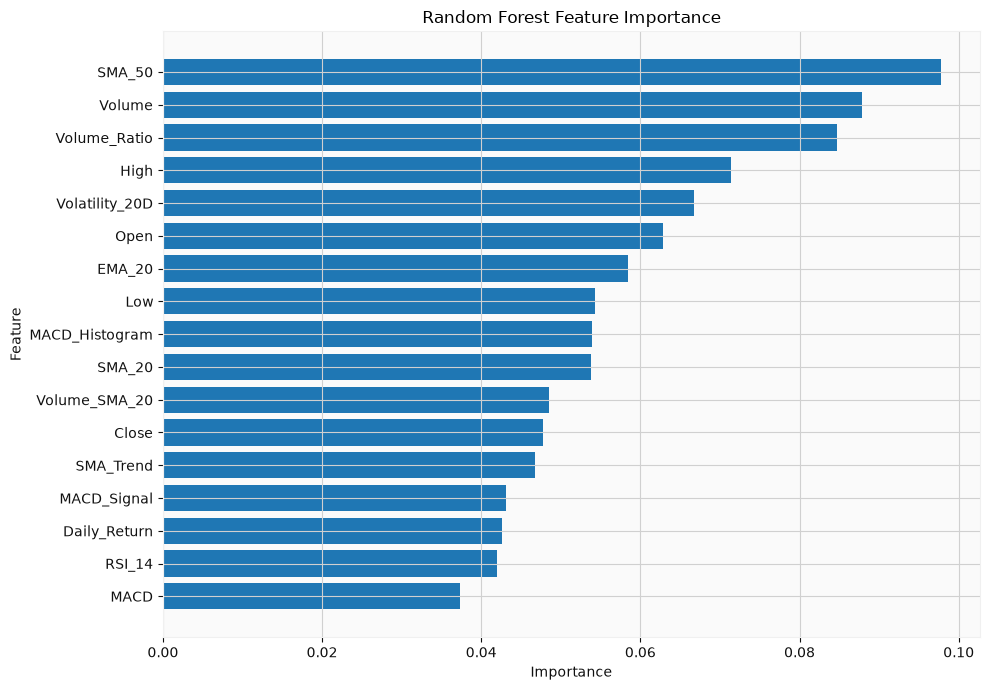

In [37]:
import matplotlib.pyplot as plt

# Plot feature importance
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [38]:
# Get prediction probabilities

rf_probability = rf_model.predict_proba(X_test)

# Probability of DOWN (class 0)
down_probability = rf_probability[:, 0]

# Probability of UP (class 1)
up_probability = rf_probability[:, 1]

# Create result DataFrame
prediction_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_pred,
    "Down_Probability": down_probability,
    "Up_Probability": up_probability
}, index=X_test.index)

print("===== PREDICTION PROBABILITIES =====")
print(prediction_results.to_string())

===== PREDICTION PROBABILITIES =====
                           Actual  Predicted  Down_Probability  Up_Probability
Date                                                                          
2026-07-27 00:00:00-04:00       1          0          0.531068        0.468932
2026-07-28 00:00:00-04:00       0          1          0.409269        0.590731
2026-07-29 00:00:00-04:00       1          0          0.521863        0.478137
2026-07-30 00:00:00-04:00       1          1          0.379413        0.620587
2026-07-31 00:00:00-04:00       1          1          0.493756        0.506244
2026-08-03 00:00:00-04:00       1          1          0.430240        0.569760
2026-08-04 00:00:00-04:00       1          0          0.618321        0.381679
2026-08-05 00:00:00-04:00       0          0          0.621048        0.378952
2026-08-06 00:00:00-04:00       1          0          0.613781        0.386219
2026-08-07 00:00:00-04:00       0          0          0.615099        0.384901
2026-08-10 00:0

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Score:
0.4605813701401937


In [44]:
# Get the best Random Forest model from GridSearchCV
best_rf = grid_search.best_estimator_

# Predict probabilities on test data
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("Best Random Forest:", best_rf)
print("ROC-AUC:", roc_auc)

Best Random Forest: RandomForestClassifier(max_depth=5, min_samples_split=5, random_state=42)
ROC-AUC: 0.5964912280701754


In [41]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support fo

In [45]:
from sklearn.metrics import roc_auc_score

y_prob = best_rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.5964912280701754


In [46]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Best model
best_rf = grid_search.best_estimator_

# Predictions
y_pred = best_rf.predict(X_test)

# Probabilities
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("===== TUNED RANDOM FOREST =====")
print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

print("===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred))

===== TUNED RANDOM FOREST =====
Accuracy: 0.5675675675675675
ROC-AUC: 0.5964912280701754

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.55      0.95      0.69        19
           1       0.75      0.17      0.27        18

    accuracy                           0.57        37
   macro avg       0.65      0.56      0.48        37
weighted avg       0.64      0.57      0.49        37

===== CONFUSION MATRIX =====
[[18  1]
 [15  3]]


In [47]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Create model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

# Predictions
gb_pred = gb_model.predict(X_test)

# Probabilities
gb_prob = gb_model.predict_proba(X_test)[:, 1]

# Metrics
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_prob)

print("===== GRADIENT BOOSTING =====")
print("Accuracy:", gb_accuracy)
print("ROC-AUC:", gb_roc_auc)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, gb_pred))

print("===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, gb_pred))

===== GRADIENT BOOSTING =====
Accuracy: 0.4594594594594595
ROC-AUC: 0.37719298245614036

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.47      0.37      0.41        19
           1       0.45      0.56      0.50        18

    accuracy                           0.46        37
   macro avg       0.46      0.46      0.46        37
weighted avg       0.46      0.46      0.45        37

===== CONFUSION MATRIX =====
[[ 7 12]
 [ 8 10]]


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

# =========================
# 1. LOGISTIC REGRESSION
# =========================

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_prob)


# =========================
# 2. ORIGINAL RANDOM FOREST
# =========================

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)


# =========================
# 3. TUNED RANDOM FOREST
# =========================

best_rf = grid_search.best_estimator_

tuned_rf_pred = best_rf.predict(X_test)
tuned_rf_prob = best_rf.predict_proba(X_test)[:, 1]

tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_pred)
tuned_rf_roc_auc = roc_auc_score(y_test, tuned_rf_prob)


# =========================
# 4. GRADIENT BOOSTING
# =========================

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_prob)


# =========================
# 5. FINAL COMPARISON
# =========================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        tuned_rf_accuracy,
        gb_accuracy
    ],
    "ROC_AUC": [
        lr_roc_auc,
        rf_roc_auc,
        tuned_rf_roc_auc,
        gb_roc_auc
    ]
})

print("===== MODEL COMPARISON =====")
print(model_comparison.to_string(index=False))

===== MODEL COMPARISON =====
              Model  Accuracy  ROC_AUC
Logistic Regression  0.513514 0.733918
      Random Forest  0.567568 0.470760
Tuned Random Forest  0.567568 0.596491
  Gradient Boosting  0.459459 0.377193


In [51]:
from sklearn.metrics import classification_report, confusion_matrix

print("===== LOGISTIC REGRESSION =====")

print("\nAccuracy:")
print(lr_accuracy)

print("\nROC-AUC:")
print(lr_roc_auc)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, lr_pred))

print("===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, lr_pred))

print("\n===== PROBABILITY RANGE =====")
print("Minimum UP probability:", lr_prob.min())
print("Maximum UP probability:", lr_prob.max())
print("Mean UP probability:", lr_prob.mean())

===== LOGISTIC REGRESSION =====

Accuracy:
0.5135135135135135

ROC-AUC:
0.7339181286549707

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      0.05      0.10        19
           1       0.50      1.00      0.67        18

    accuracy                           0.51        37
   macro avg       0.75      0.53      0.38        37
weighted avg       0.76      0.51      0.38        37

===== CONFUSION MATRIX =====
[[ 1 18]
 [ 0 18]]

===== PROBABILITY RANGE =====
Minimum UP probability: 0.39831882985596107
Maximum UP probability: 0.9456537483500148
Mean UP probability: 0.7710230047747642


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

results = []

for threshold in thresholds:

    pred = (lr_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "Predicted_UP": pred.sum()
    })

threshold_results = pd.DataFrame(results)

print("===== THRESHOLD ANALYSIS =====")
print(threshold_results.to_string(index=False))

===== THRESHOLD ANALYSIS =====
 Threshold  Accuracy  Precision   Recall  Predicted_UP
       0.3  0.486486   0.486486 1.000000            37
       0.4  0.513514   0.500000 1.000000            36
       0.5  0.513514   0.500000 1.000000            36
       0.6  0.540541   0.514286 1.000000            35
       0.7  0.594595   0.555556 0.833333            27
       0.8  0.567568   0.555556 0.555556            18


In [53]:
# ==============================
# FEATURE IMPORTANCE ANALYSIS
# ==============================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("===== FEATURE IMPORTANCE =====")
print(feature_importance.to_string(index=False))

===== FEATURE IMPORTANCE =====
       Feature  Importance
        Volume    0.093366
        SMA_50    0.088490
  Volume_Ratio    0.070618
        EMA_20    0.069249
 Volume_SMA_20    0.069052
Volatility_20D    0.065988
           Low    0.060397
MACD_Histogram    0.054434
          Open    0.052674
          High    0.052357
        RSI_14    0.051927
         Close    0.049928
     SMA_Trend    0.046658
   MACD_Signal    0.045550
  Daily_Return    0.044379
        SMA_20    0.043669
          MACD    0.041266


In [54]:
# ==========================================
# TOP FEATURE SELECTION
# ==========================================

top_features = feature_importance["Feature"].head(8).tolist()

print("===== SELECTED FEATURES =====")
print(top_features)

# Create reduced datasets
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

print("\n===== SELECTED DATA SHAPE =====")
print("X_train_selected:", X_train_selected.shape)
print("X_test_selected :", X_test_selected.shape) 
# ==========================================
# RANDOM FOREST WITH SELECTED FEATURES
# ==========================================

selected_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

selected_rf.fit(X_train_selected, y_train)

selected_pred = selected_rf.predict(X_test_selected)
selected_prob = selected_rf.predict_proba(X_test_selected)[:, 1]

selected_accuracy = accuracy_score(y_test, selected_pred)
selected_roc_auc = roc_auc_score(y_test, selected_prob)

print("===== SELECTED FEATURE RANDOM FOREST =====")
print("Accuracy:", selected_accuracy)
print("ROC-AUC:", selected_roc_auc)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, selected_pred))

print("===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, selected_pred))

===== SELECTED FEATURES =====
['Volume', 'SMA_50', 'Volume_Ratio', 'EMA_20', 'Volume_SMA_20', 'Volatility_20D', 'Low', 'MACD_Histogram']

===== SELECTED DATA SHAPE =====
X_train_selected: (144, 8)
X_test_selected : (37, 8)
===== SELECTED FEATURE RANDOM FOREST =====
Accuracy: 0.5675675675675675
ROC-AUC: 0.5584795321637428

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.55      0.95      0.69        19
           1       0.75      0.17      0.27        18

    accuracy                           0.57        37
   macro avg       0.65      0.56      0.48        37
weighted avg       0.64      0.57      0.49        37

===== CONFUSION MATRIX =====
[[18  1]
 [15  3]]


In [55]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Time-series split
tscv = TimeSeriesSplit(n_splits=5)

# Model
cv_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

# Cross-validation
cv_scores = cross_val_score(
    cv_rf,
    X_train,
    y_train,
    cv=tscv,
    scoring="accuracy"
)

print("===== TIME SERIES CROSS VALIDATION =====")
print("Fold Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

===== TIME SERIES CROSS VALIDATION =====
Fold Scores: [0.625      0.54166667 0.54166667 0.5        0.45833333]
Mean CV Accuracy: 0.5333333333333333
Standard Deviation: 0.055277079839256664


In [57]:
# ==========================================
# SIMPLE ML BACKTEST
# ==========================================

import pandas as pd
import numpy as np

# Predictions
backtest = X_test.copy()

backtest["Actual"] = y_test.values
backtest["Predicted"] = best_rf.predict(X_test)
backtest["Up_Probability"] = best_rf.predict_proba(X_test)[:, 1]

# Get actual Close and Next_Close from the same test dates
backtest["Next_Day_Return"] = (
    ml_data.loc[X_test.index, "Next_Close"] /
    ml_data.loc[X_test.index, "Close"] - 1
)

# Strategy:
# Prediction = 1 -> Buy/Hold
# Prediction = 0 -> No position

backtest["Strategy_Return"] = (
    backtest["Predicted"] * backtest["Next_Day_Return"]
)

# Cumulative returns
backtest["Market_Cumulative"] = (
    1 + backtest["Next_Day_Return"]
).cumprod()

backtest["Strategy_Cumulative"] = (
    1 + backtest["Strategy_Return"]
).cumprod()

print("===== BACKTEST RESULTS =====")

print(
    backtest[
        [
            "Actual",
            "Predicted",
            "Up_Probability",
            "Next_Day_Return",
            "Strategy_Return"
        ]
    ].head(10)
)

print("\n===== FINAL CUMULATIVE VALUES =====")

print(
    "Market:",
    backtest["Market_Cumulative"].iloc[-1]
)

print(
    "Strategy:",
    backtest["Strategy_Cumulative"].iloc[-1]
)

===== BACKTEST RESULTS =====
                           Actual  Predicted  Up_Probability  Next_Day_Return  \
Date                                                                            
2026-07-27 00:00:00-04:00       1          0        0.438245         0.002544   
2026-07-28 00:00:00-04:00       0          1        0.587841        -0.035531   
2026-07-29 00:00:00-04:00       1          0        0.487625         0.026472   
2026-07-30 00:00:00-04:00       1          1        0.594717         0.029276   
2026-07-31 00:00:00-04:00       1          1        0.518829         0.029340   
2026-08-03 00:00:00-04:00       1          1        0.559376         0.025648   
2026-08-04 00:00:00-04:00       1          0        0.415269         0.034349   
2026-08-05 00:00:00-04:00       0          0        0.369305        -0.001049   
2026-08-06 00:00:00-04:00       1          0        0.391334         0.022695   
2026-08-07 00:00:00-04:00       0          0        0.364579        -0.028621   

In [58]:
# ==========================================
# BACKTEST PERFORMANCE METRICS
# ==========================================

# Total Returns
market_return = (
    backtest["Market_Cumulative"].iloc[-1] - 1
)

strategy_return = (
    backtest["Strategy_Cumulative"].iloc[-1] - 1
)

# Win Rate
trades = backtest[backtest["Predicted"] == 1]

winning_trades = (
    trades["Strategy_Return"] > 0
).sum()

total_trades = len(trades)

win_rate = (
    winning_trades / total_trades
    if total_trades > 0 else 0
)

# Maximum Drawdown
strategy_curve = backtest["Strategy_Cumulative"]

rolling_max = strategy_curve.cummax()

drawdown = (
    strategy_curve / rolling_max - 1
)

max_drawdown = drawdown.min()

# Sharpe Ratio
strategy_returns = backtest["Strategy_Return"]

sharpe_ratio = (
    strategy_returns.mean() /
    strategy_returns.std()
) * np.sqrt(252)

print("===== BACKTEST PERFORMANCE =====")

print(f"Market Return:   {market_return * 100:.2f}%")
print(f"Strategy Return: {strategy_return * 100:.2f}%")

print(f"Win Rate:        {win_rate * 100:.2f}%")

print(f"Max Drawdown:    {max_drawdown * 100:.2f}%")

print(f"Sharpe Ratio:    {sharpe_ratio:.2f}")

print(f"\nTotal Trades:    {total_trades}")

===== BACKTEST PERFORMANCE =====
Market Return:   11.74%
Strategy Return: 4.80%
Win Rate:        75.00%
Max Drawdown:    -3.55%
Sharpe Ratio:    2.10

Total Trades:    4


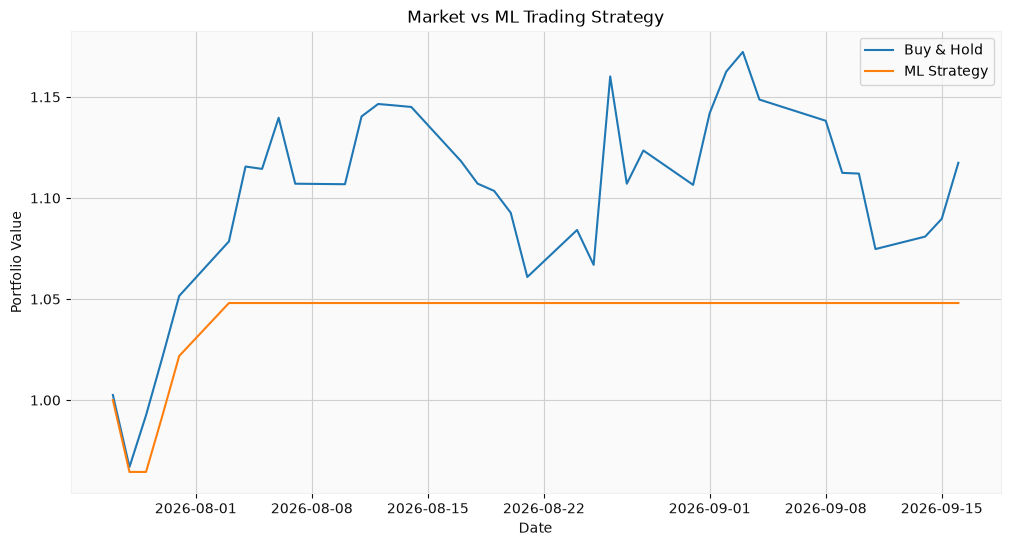

In [59]:
# ==========================================
# EQUITY CURVE
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    backtest.index,
    backtest["Market_Cumulative"],
    label="Buy & Hold"
)

plt.plot(
    backtest.index,
    backtest["Strategy_Cumulative"],
    label="ML Strategy"
)

plt.title("Market vs ML Trading Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.show()

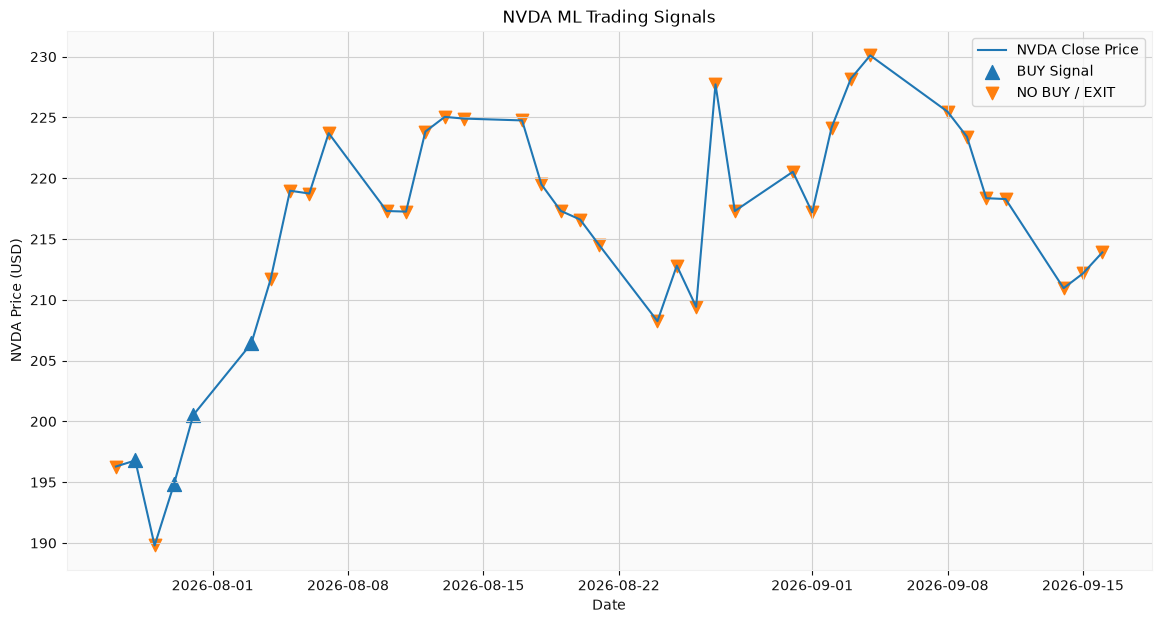

In [60]:
# ==========================================
# BUY / NO-BUY SIGNAL VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# NVDA price
plt.plot(
    backtest.index,
    X_test["Close"],
    label="NVDA Close Price"
)

# BUY signals
buy_signals = backtest["Predicted"] == 1

plt.scatter(
    backtest.index[buy_signals],
    X_test.loc[buy_signals, "Close"],
    marker="^",
    s=100,
    label="BUY Signal"
)

# NO BUY / EXIT signals
sell_signals = backtest["Predicted"] == 0

plt.scatter(
    backtest.index[sell_signals],
    X_test.loc[sell_signals, "Close"],
    marker="v",
    s=80,
    label="NO BUY / EXIT"
)

plt.title("NVDA ML Trading Signals")
plt.xlabel("Date")
plt.ylabel("NVDA Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

In [61]:
# ==========================================
# LATEST NVDA PREDICTION
# ==========================================

# Latest row from the feature dataset
latest_data = ml_data.iloc[[-1]].copy()

# Same 17 features used during training
feature_columns = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Daily_Return',
    'Volatility_20D',
    'SMA_20',
    'SMA_50',
    'SMA_Trend',
    'EMA_20',
    'RSI_14',
    'MACD',
    'MACD_Signal',
    'MACD_Histogram',
    'Volume_SMA_20',
    'Volume_Ratio'
]

# Extract latest features
X_latest = latest_data[feature_columns]

# Prediction
latest_prediction = best_rf.predict(X_latest)[0]

# Probability
latest_probability = best_rf.predict_proba(X_latest)[0]

down_probability = latest_probability[0]
up_probability = latest_probability[1]

# Trading signal
if latest_prediction == 1:
    signal = "BUY"
else:
    signal = "NO BUY / EXIT"

print("===== LATEST NVDA PREDICTION =====")

print("Date:", latest_data.index[0])
print("Close Price:", latest_data["Close"].iloc[0])

print("\nDown Probability:",
      f"{down_probability:.2%}")

print("Up Probability:",
      f"{up_probability:.2%}")

print("\nPrediction:",
      "UP" if latest_prediction == 1 else "DOWN")

print("Trading Signal:",
      signal)

===== LATEST NVDA PREDICTION =====
Date: 2026-09-16 00:00:00-04:00
Close Price: 213.89999389648438

Down Probability: 63.31%
Up Probability: 36.69%

Prediction: DOWN
Trading Signal: NO BUY / EXIT


In [62]:
# ==========================================
# SAVE TRAINED MODEL
# ==========================================

import joblib

# Save trained model
joblib.dump(best_rf, "nvda_random_forest.pkl")

# Save feature names
joblib.dump(feature_columns, "nvda_features.pkl")

print("===== MODEL SAVED =====")
print("Model: nvda_random_forest.pkl")
print("Features: nvda_features.pkl")

===== MODEL SAVED =====
Model: nvda_random_forest.pkl
Features: nvda_features.pkl


In [63]:
import os

print("Model exists:", os.path.exists("nvda_random_forest.pkl"))
print("Features exists:", os.path.exists("nvda_features.pkl"))

Model exists: True
Features exists: True


In [64]:
# ==========================================
# REUSABLE NVDA PREDICTION FUNCTION
# ==========================================

def predict_nvda(data, model, features):

    latest = data[features].iloc[[-1]]

    prediction = model.predict(latest)[0]
    probabilities = model.predict_proba(latest)[0]

    down_probability = probabilities[0]
    up_probability = probabilities[1]

    if prediction == 1:
        signal = "BUY"
        direction = "UP"
    else:
        signal = "NO BUY / EXIT"
        direction = "DOWN"

    return {
        "Date": data.index[-1],
        "Close": data["Close"].iloc[-1],
        "Prediction": direction,
        "Down_Probability": down_probability,
        "Up_Probability": up_probability,
        "Trading_Signal": signal
    }


# Run prediction
result = predict_nvda(
    ml_data,
    best_rf,
    feature_columns
)

print("===== FINAL PREDICTION =====")

for key, value in result.items():
    print(f"{key}: {value}")

===== FINAL PREDICTION =====
Date: 2026-09-16 00:00:00-04:00
Close: 213.89999389648438
Prediction: DOWN
Down_Probability: 0.6330626538518438
Up_Probability: 0.3669373461481562
Trading_Signal: NO BUY / EXIT


In [65]:
# ============================================
# FINAL PRODUCTION MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier
import joblib
import pandas as pd
import numpy as np

# --------------------------------------------
# 1. Features and target
# --------------------------------------------

features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Daily_Return',
    'Volatility_20D',
    'SMA_20',
    'SMA_50',
    'SMA_Trend',
    'EMA_20',
    'RSI_14',
    'MACD',
    'MACD_Signal',
    'MACD_Histogram',
    'Volume_SMA_20',
    'Volume_Ratio'
]

X_final = ml_data[features]
y_final = ml_data['Target']

print("X shape:", X_final.shape)
print("y shape:", y_final.shape)

# --------------------------------------------
# 2. Train final production model
# --------------------------------------------

final_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

final_rf.fit(X_final, y_final)

print("\n===== FINAL PRODUCTION MODEL =====")
print(final_rf)

# --------------------------------------------
# 3. Save model and features
# --------------------------------------------

joblib.dump(final_rf, "nvda_final_model.pkl")
joblib.dump(features, "nvda_final_features.pkl")

print("\nModel saved:")
print("nvda_final_model.pkl")
print("nvda_final_features.pkl")

X shape: (181, 17)
y shape: (181,)

===== FINAL PRODUCTION MODEL =====
RandomForestClassifier(max_depth=5, min_samples_split=5, random_state=42)

Model saved:
nvda_final_model.pkl
nvda_final_features.pkl


In [67]:
# ============================================
# FINAL LATEST NVDA PREDICTION - FIXED
# ============================================

# Latest row from ML dataset
latest_data = ml_data[features].iloc[[-1]]

# Prediction
prediction = final_rf.predict(latest_data)[0]

# Probabilities
probabilities = final_rf.predict_proba(latest_data)[0]

down_probability = probabilities[0]
up_probability = probabilities[1]

# Trading signal
if up_probability >= 0.60:
    signal = "BUY"
elif up_probability <= 0.40:
    signal = "NO BUY / EXIT"
else:
    signal = "HOLD / WAIT"

print("===== FINAL NVDA PREDICTION =====")
print("Date:", latest_data.index[0])
print("Close Price:", latest_data["Close"].iloc[0])

print("\nDown Probability:", f"{down_probability:.2%}")
print("Up Probability:", f"{up_probability:.2%}")

print("\nPrediction:", "UP" if prediction == 1 else "DOWN")
print("Trading Signal:", signal)

===== FINAL NVDA PREDICTION =====
Date: 2026-09-16 00:00:00-04:00
Close Price: 213.89999389648438

Down Probability: 32.75%
Up Probability: 67.25%

Prediction: UP
Trading Signal: BUY
